<a href="https://colab.research.google.com/github/NadimD9000-byte/Nadim-s-project/blob/main/Timeseries_forcasting_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
file_path = '/content/drive/MyDrive/Ml_project/train.csv'
df = pd.read_csv(file_path)
df.head()
df[['day','month','week']] =df['week'].str.split('/',expand =True)
df = df.drop('week',axis = 1)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X,y = df.drop('units_sold',axis = 1), df['units_sold']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)


In [ ]:
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1)

In [ ]:
model.score(X_test,y_test)

0.7767654511535956

In [ ]:
from sklearn.metrics import root_mean_squared_error
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test,y_pred)
print(rmse)

27.064011498081697


In [ ]:
df.units_sold.describe( )

,units_sold
count,150150.000000
mean,51.674206
std,60.207904
min,1.000000
25%,20.000000
50%,35.000000
75%,62.000000
max,2876.000000


<Axes: >

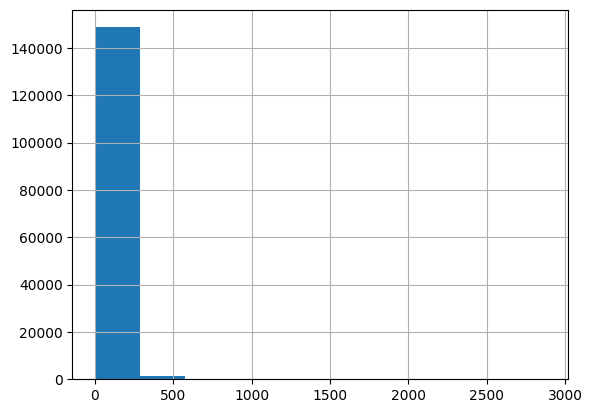

In [ ]:
df.units_sold.hist( )

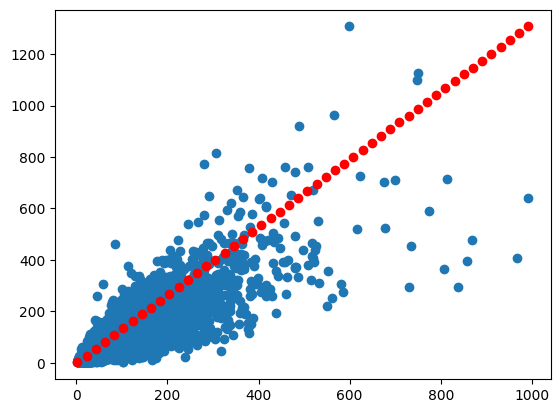

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_pred,y_test)
plt.scatter(np.linspace(y_pred.min(),y_pred.max()),np.linspace(y_test.min(),y_test.max()),color = 'red')


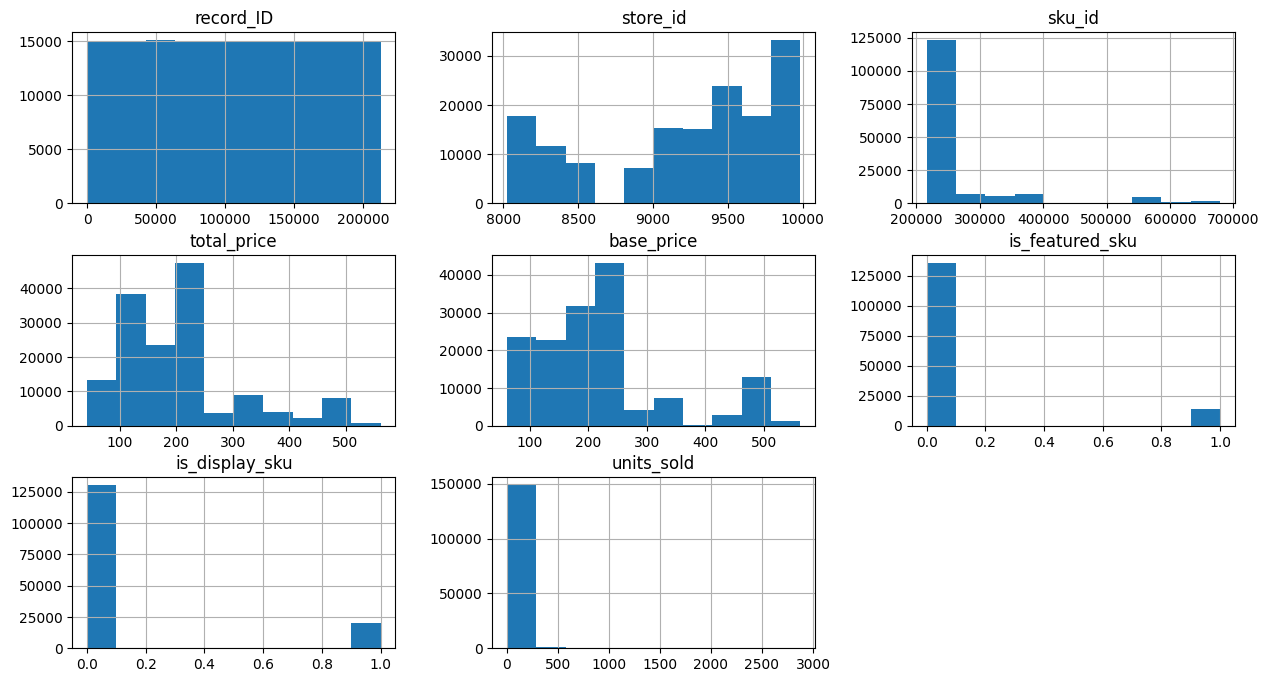

In [ ]:
df.hist(figsize=(15,8))
plt.show( )

In [ ]:
if 'record_ID' in df.columns:
    df = df.drop('record_ID',axis=1)

In [ ]:
len(df.store_id.unique())

76

In [ ]:
len(df.sku_id.unique())

28

In [ ]:
df =df[df.units_sold < df.units_sold.quantile(0.99)]

<Axes: >

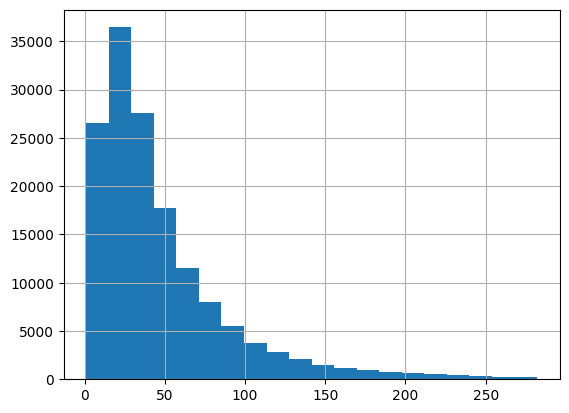

In [ ]:
df.units_sold.hist(bins=20)

In [ ]:
if 'store_id' in df.columns:
    df = df.join(pd.get_dummies(df.store_id,prefix='store_id')).drop('store_id',axis=1)
if 'sku_id' in df.columns:
    df = df.join(pd.get_dummies(df.sku_id,prefix='sku_id')).drop('sku_id',axis=1)

In [ ]:
model = RandomForestRegressor(n_jobs=-1)
X,y = df.drop('units_sold',axis = 1), df['units_sold']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)


In [ ]:
model.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1)

In [ ]:
model.score(X_test,y_test)

0.8119102812425882

In [ ]:
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test,y_pred)
rmse

18.51275825364674

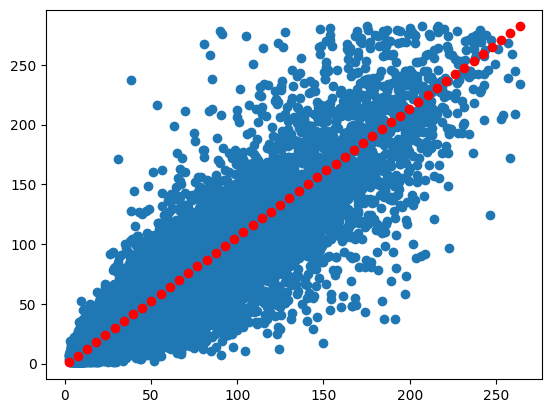

In [ ]:
plt.scatter(y_pred,y_test)
plt.scatter(np.linspace(y_pred.min(),y_pred.max()),np.linspace(y_test.min(),y_test.max()),color = 'red')


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [10,20],
    'min_samples_split':[2,3]
}
model= RandomForestRegressor(n_jobs=-1)
grid_search = GridSearchCV(model,param_grid,verbose=2,cv=3)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...............min_samples_split=2, n_estimators=10; total time=  11.5s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=  10.2s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=  10.3s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=  21.7s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=  21.9s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=  20.3s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=  10.5s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=  10.5s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=  10.8s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=  20.0s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=  21.2s
[CV] END ...............min_samples_split=3, n_es

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'min_samples_split': [2, 3], 'n_estimators': [10, 20]},
             verbose=2)

In [ ]:
best_model = grid_search.best_estimator_
grid_search.best_params_

{'min_samples_split': 3, 'n_estimators': 20}

In [ ]:
best_model.score(X_test,y_test)

0.8082503650898039